In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset

In [3]:
df=pd.read_csv("data.csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


Data cleaning and preparation

In [4]:
df['rate']=df['rate'].str.extract(r'(\d+\.?\d*)\s*/\s*\d+')
df['rate']=df['rate'].astype(float)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


In [6]:
df.isna().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Popular restaurant categories

/tmp/ipykernel_20229/1578521288.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['listed_in(type)'],palette='viridis')


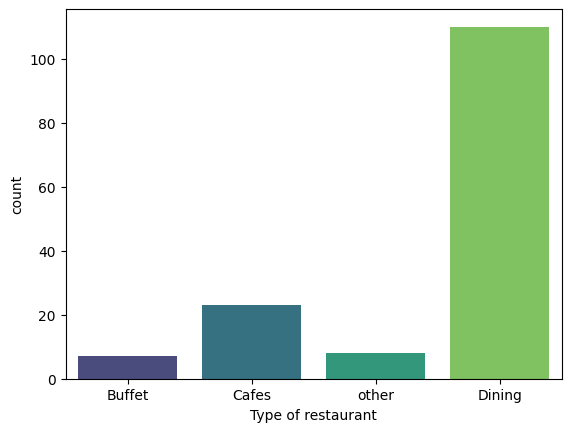

In [7]:
sns.countplot(x=df['listed_in(type)'],palette='viridis')
plt.xlabel("Type of restaurant")
plt.show()

Votes by Restaurant Type

In [8]:
vote_per_category=df.groupby('listed_in(type)')['votes'].sum().reset_index()
vote_per_category

,listed_in(type),votes
0,Buffet,3028
1,Cafes,6434
2,Dining,20363
3,other,9367


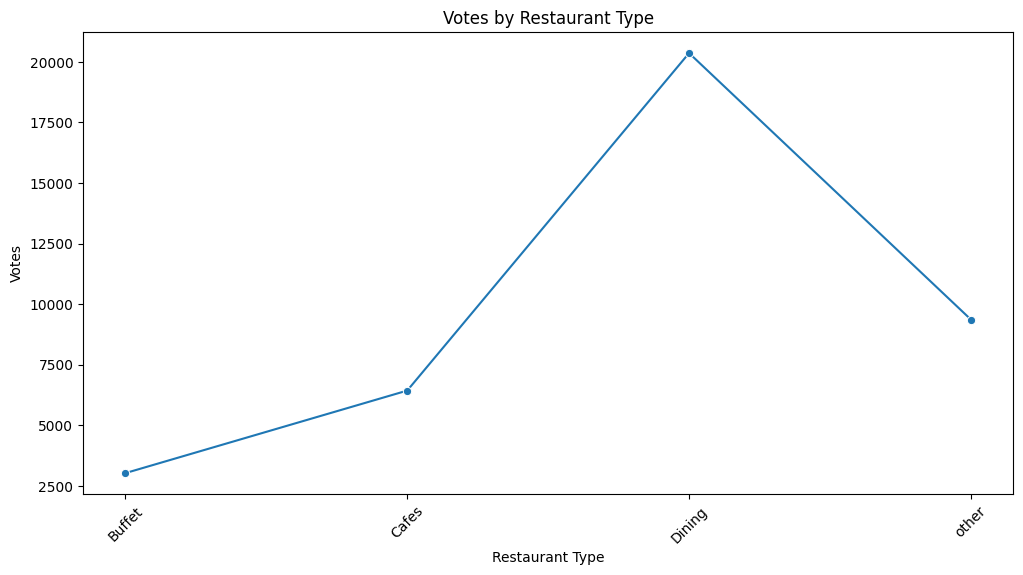

In [9]:
plt.figure(figsize=(12,6))
sns.lineplot(x='listed_in(type)',y='votes',data=vote_per_category,marker='o')
plt.title('Votes by Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Votes')
plt.xticks(rotation=45)
plt.show()

Most Voted Restaurant

In [10]:
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


In [11]:
max_votes=df['votes'].max()
restaurant_with_max_votes = df.loc[df['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: str


Online Order Availability

In [12]:
restaurant_with_online_orders = df[df['online_order'] == 'Yes']['name']
print(restaurant_with_online_orders)

0                                            Jalsa
1                                   Spice Elephant
2                                  San Churro Cafe
5                                  Timepass Dinner
7                                           Onesta
8                                   Penthouse Cafe
9                                        Smacznego
10                                    Village Café
11                                    Cafe Shuffle
12                                The Coffee Shack
14                                 San Churro Cafe
15                                   Cafe Vivacity
16                                    Catch-up-ino
17                                Kirthi's Biryani
19                   360 Atoms Restaurant And Cafe
20                                The Vintage Cafe
21                                    Woodee Pizza
23                                    My Tea House
26                                    Coffee Tindi
30                             

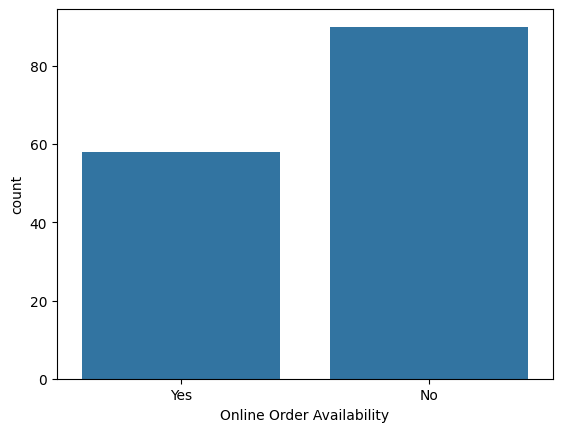

In [13]:
sns.countplot(x=df['online_order'])
plt.xlabel("Online Order Availability")
plt.show()

Analyze ratings

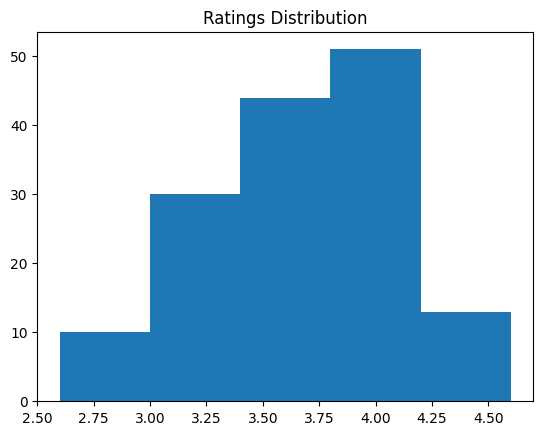

In [14]:
plt.hist(df['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

Approximate cost for couples

/tmp/ipykernel_20229/2383715634.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['approx_cost(for two people)'],palette='viridis')


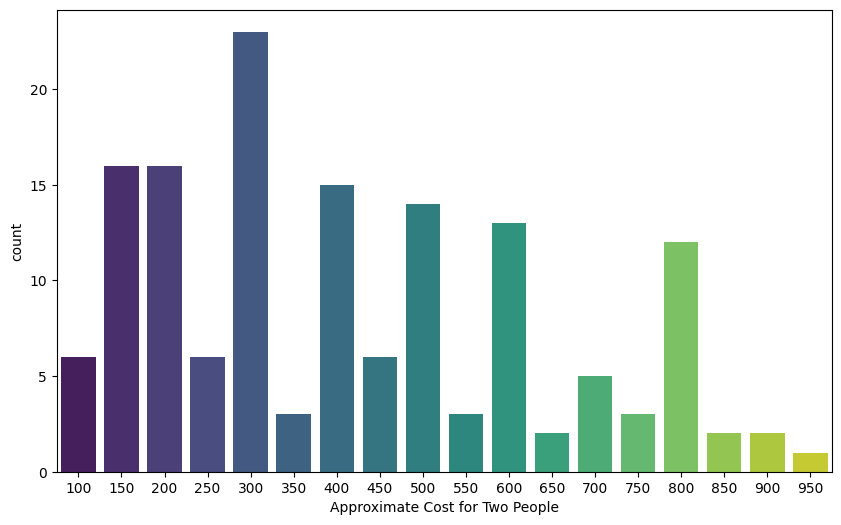

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['approx_cost(for two people)'],palette='viridis')
plt.xlabel("Approximate Cost for Two People")
plt.show()

Ratings comparison - online vs offline orders

<Axes: xlabel='online_order', ylabel='rate'>

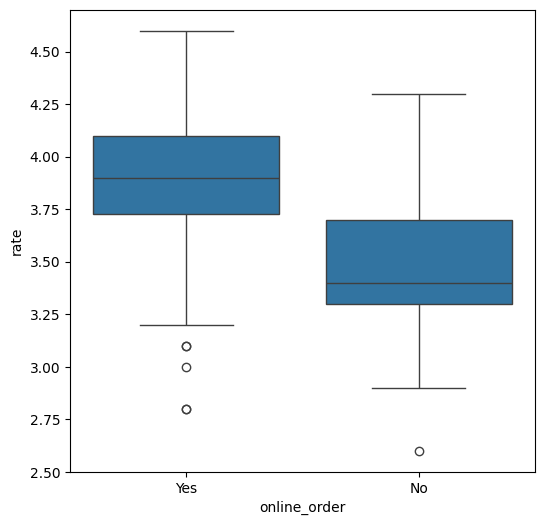

In [16]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)

Order mode preferences by restaurant type

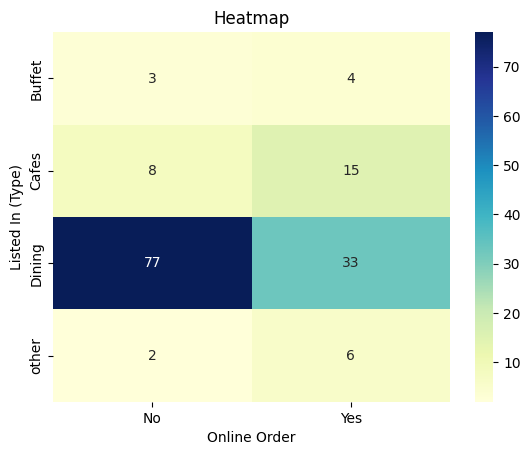

In [17]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

In [18]:
# Top 10 Highest Rated Restaurants
top_rated = df.nlargest(10, 'rate')
print("Top 10 Highest Rated Restaurants:")
print(top_rated[['name', 'rate', 'votes', 'approx_cost(for two people)']])

Top 10 Highest Rated Restaurants:
                      name  rate  votes  approx_cost(for two people)
7                   Onesta   4.6   2556                          600
44                  Onesta   4.6   2556                          600
38       Empire Restaurant   4.4   4884                          750
86           Meghana Foods   4.4   4401                          600
52  Corner House Ice Cream   4.3    345                          400
9                Smacznego   4.2    504                          550
11            Cafe Shuffle   4.2    150                          600
12        The Coffee Shack   4.2    164                          500
34                  Faasos   4.2    415                          500
37         Szechuan Dragon   4.2   1647                          600
